# Capstone Project Model 3: Customer Rating Prediction team 89

**Students:** Ziad Salah , Ziad tamer , Rana Ali , Rawan Samir , Shahd Abdallah

**Track:** Data Science Machine Learning

**Chosen Model:** Model 3 — Rating Prediction (Regression)

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [87]:
import joblib

In [88]:
pd.set_option('display.max_columns', 50)

## Load Data



In [89]:
orders = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_customers_dataset.csv')
items = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_products_dataset.csv')
payments = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_sellers_dataset.csv')
cat_translation = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/product_category_name_translation.csv')

orders_raw = orders.copy()

In [90]:
print('orders:', orders.shape)
print('customers:', customers.shape)
print('items:', items.shape)
print('products:', products.shape)
print('payments:', payments.shape)
print('reviews:', reviews.shape)
print('sellers:', sellers.shape)
print('cat_translation:', cat_translation.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)
sellers: (3095, 4)
cat_translation: (73, 2)


In [91]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [92]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [93]:
orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


## Data Audit


In [94]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [95]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [96]:
(orders == "unknown").sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [97]:
missing = pd.DataFrame({'count': orders.isna().sum(), 'percent': orders.isna().mean().mul(100).round(2)}).sort_values('percent', ascending=False)

In [98]:
print(missing)

                               count  percent
order_delivered_customer_date   2965     2.98
order_delivered_carrier_date    1783     1.79
order_approved_at                160     0.16
order_id                           0     0.00
order_purchase_timestamp           0     0.00
order_status                       0     0.00
customer_id                        0     0.00
order_estimated_delivery_date      0     0.00


In [99]:
print('duplicate rows:', orders.duplicated().sum())
print('duplicate order_id:', orders.duplicated('order_id').sum())

duplicate rows: 0
duplicate order_id: 0


In [100]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [101]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [102]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [103]:
null_tokens = ['NA', 'N/A', 'Null', 'null', '-', '', ' ']

for i in orders.select_dtypes(include='object').columns:
    
    hits = orders[i].isin(null_tokens).sum()
    if hits > 0:
        print(i, hits)

print('done checking nulls')
print('found null values in objects: ', hits)

done checking nulls
found null values in objects:  0


In [104]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [105]:
print(reviews['review_score'].value_counts(normalize=True).multiply(100).round(2))

review_score
5    57.78
4    19.29
1    11.51
3     8.24
2     3.18
Name: proportion, dtype: float64


In [106]:
print(reviews.isna().sum())


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [107]:
print('duplicate order_id in reviews :', reviews.duplicated('order_id').sum())

duplicate order_id in reviews : 551


## Preprocessing

In [108]:
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])


In [109]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [110]:
products_category = products.merge(cat_translation, on='product_category_name',how='left')

products_category['product_category_name_english'] = ( products_category['product_category_name_english'].fillna('unknown'))

items_full = items.merge( products_category[['product_id', 'product_category_name_english']],on='product_id', how='left')

items_full = items_full.merge(sellers[['seller_id', 'seller_state']],on='seller_id',how='left')

items_full.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,PR


In [111]:
products_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [112]:
def most_common(series):
    return series.mode().iloc[0] if not series.mode().empty else 'unknown'

items_agg = items_full.groupby('order_id').agg(n_items=('order_item_id', 'count'),n_distinct_products=('product_id', 'nunique'),n_distinct_sellers=('seller_id', 'nunique'),total_price=('price', 'sum'),avg_item_price=('price', 'mean'),total_freight=('freight_value', 'sum'),).reset_index()

dominant_category = items_full.groupby('order_id')['product_category_name_english'].agg(most_common).reset_index()
dominant_category.columns = ['order_id', 'product_category']

dominant_seller_state = items_full.groupby('order_id')['seller_state'].agg(most_common).reset_index()
dominant_seller_state.columns = ['order_id', 'seller_state']

items_agg = items_agg.merge(dominant_category, on='order_id', how='left')
items_agg = items_agg.merge(dominant_seller_state, on='order_id', how='left')
items_agg.head()

,order_id,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,58.90,13.29,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,239.90,19.93,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,199.00,17.87,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.99,12.79,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,199.90,18.14,garden_tools,PR


In [113]:
payments_agg = payments.groupby('order_id').agg(total_payment_value=('payment_value', 'sum'),max_installments=('payment_installments', 'max'),n_payment_methods=('payment_type', 'nunique'),).reset_index()

dominant_payment = payments.groupby('order_id')['payment_type'].agg(most_common).reset_index()
dominant_payment.columns = ['order_id', 'payment_type']
payments_agg = payments_agg.merge(dominant_payment, on='order_id', how='left')
payments_agg.head()

,order_id,total_payment_value,max_installments,n_payment_methods,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [114]:
reviews_clean = (reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last'))

reviews_clean = reviews_clean[['order_id', 'review_score']]

reviews_clean.head()


,order_id,review_score
37547,bfbd0f9bdef84302105ad712db648a6c,1
5503,e5215415bb6f76fe3b7cb68103a0d1c0,1
60439,e2144124f98f3bf46939bc5183104041,4
28075,b8b9d7046c083150cb5360b83a8ebb51,5
41042,9aa3197e4887919fde0307fc23601d7a,4


In [115]:
df = orders.merge(customers[['customer_id', 'customer_state']],on='customer_id',how='left')

df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(reviews_clean, on='order_id', how='left')

print("Merged shape:", df.shape)

df.head()


Merged shape: (99441, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state,total_payment_value,max_installments,n_payment_methods,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,1.0,1.0,1.0,29.99,29.99,8.72,housewares,SP,38.71,1.0,2.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,1.0,1.0,1.0,118.70,118.70,22.76,perfumery,SP,141.46,1.0,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,1.0,1.0,1.0,159.90,159.90,19.22,auto,SP,179.12,3.0,1.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,1.0,1.0,1.0,45.00,45.00,27.20,pet_shop,MG,72.20,1.0,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,1.0,1.0,1.0,19.90,19.90,8.72,stationery,SP,28.62,1.0,1.0,credit_card,5.0


In [116]:
before = len(df)
df = df.dropna(subset=['review_score']).copy()
print(f'dropped {before - len(df)} rows with no review (missing target)')

before = len(df)
df = df.dropna(subset=['n_items']).copy()
print(f'dropped {before - len(df)} rows with no matching order items')

before = len(df)
df = df.dropna(subset=['order_delivered_customer_date']).copy()
print(f'dropped {before - len(df)} rows with missing delivery date')

df['seller_state'] = df['seller_state'].fillna('unknown')

before = len(df)
df = df.dropna(subset=['total_payment_value']).copy()
print(f'dropped {before - len(df)} rows with no matching payment record')

df['review_score'] = df['review_score'].astype(int)
print('final cleaned shape:', df.shape)

dropped 768 rows with no review (missing target)
dropped 756 rows with no matching order items
dropped 2087 rows with missing delivery date
dropped 1 rows with no matching payment record
final cleaned shape: (95829, 22)


In [117]:
print("Invalid item count:", (df['n_items'] <= 0).sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate order_id:", df.duplicated('order_id').sum())


Invalid item count: 0
Duplicate rows: 0
Duplicate order_id: 0


## Feature Engineering

In [118]:
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)


df['approval_time_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
df['approval_time_hours'] = df['approval_time_hours'].fillna(df['approval_time_hours'].median())

print('overall late-delivery rate:', df['is_late'].mean().round(4))

overall late-delivery rate: 0.0666


In [119]:
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_weekday'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_hour'] = df['order_purchase_timestamp'].dt.hour
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
              6: 'Winter', 7: 'Winter', 8: 'Winter',
              9: 'Spring', 10: 'Spring', 11: 'Spring'}

              
df['season'] = df['order_month'].map(season_map)
df[['order_month', 'season']].drop_duplicates().sort_values('order_month')

,order_month,season
8,1,Summer
4,2,Summer
14,3,Autumn
31,4,Autumn
7,5,Autumn
12,6,Winter
1,7,Winter
2,8,Winter
20,9,Spring
0,10,Spring


In [120]:
df['same_state_delivery'] = (df['customer_state'] == df['seller_state']).astype(int)

df['freight_ratio'] = (df['total_freight'] / df['total_price'])



In [121]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state,total_payment_value,max_installments,n_payment_methods,payment_type,review_score,delivery_delay_days,is_late,approval_time_hours,order_month,order_weekday,order_hour,is_weekend,season,same_state_delivery,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,1.0,1.0,1.0,29.99,29.99,8.72,housewares,SP,38.71,1.0,2.0,voucher,4,-8,0,0.178333,10,0,10,0,Spring,1,0.290764
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,1.0,1.0,1.0,118.70,118.70,22.76,perfumery,SP,141.46,1.0,1.0,boleto,4,-6,0,30.713889,7,1,20,0,Winter,0,0.191744
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,1.0,1.0,1.0,159.90,159.90,19.22,auto,SP,179.12,3.0,1.0,credit_card,5,-18,0,0.276111,8,2,8,0,Winter,0,0.120200
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,1.0,1.0,1.0,45.00,45.00,27.20,pet_shop,MG,72.20,1.0,1.0,credit_card,5,-13,0,0.298056,11,5,19,1,Spring,0,0.604444
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,1.0,1.0,1.0,19.90,19.90,8.72,stationery,SP,28.62,1.0,1.0,credit_card,5,-10,0,1.030556,2,1,21,0,Summer,1,0.438191


In [122]:
df.shape

(95829, 32)

In [123]:
drop_cols = [
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_status'
]

df_model = df.drop(columns=drop_cols)



In [124]:
print(df_model.shape)
df_model.head()

(95829, 24)


,customer_state,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state,total_payment_value,max_installments,n_payment_methods,payment_type,review_score,delivery_delay_days,is_late,approval_time_hours,order_month,order_weekday,order_hour,is_weekend,season,same_state_delivery,freight_ratio
0,SP,1.0,1.0,1.0,29.99,29.99,8.72,housewares,SP,38.71,1.0,2.0,voucher,4,-8,0,0.178333,10,0,10,0,Spring,1,0.290764
1,BA,1.0,1.0,1.0,118.70,118.70,22.76,perfumery,SP,141.46,1.0,1.0,boleto,4,-6,0,30.713889,7,1,20,0,Winter,0,0.191744
2,GO,1.0,1.0,1.0,159.90,159.90,19.22,auto,SP,179.12,3.0,1.0,credit_card,5,-18,0,0.276111,8,2,8,0,Winter,0,0.120200
3,RN,1.0,1.0,1.0,45.00,45.00,27.20,pet_shop,MG,72.20,1.0,1.0,credit_card,5,-13,0,0.298056,11,5,19,1,Spring,0,0.604444
4,SP,1.0,1.0,1.0,19.90,19.90,8.72,stationery,SP,28.62,1.0,1.0,credit_card,5,-10,0,1.030556,2,1,21,0,Summer,1,0.438191


## EDA

In [125]:
print(df_model.shape)
df_model.describe()

(95829, 24)


,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,total_payment_value,max_installments,n_payment_methods,review_score,delivery_delay_days,is_late,approval_time_hours,order_month,order_weekday,order_hour,is_weekend,same_state_delivery,freight_ratio
count,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000,95829.000000
mean,1.141262,1.038318,1.013848,136.798419,125.041260,22.762669,159.590528,2.925722,1.022592,4.155777,-11.914567,0.066587,10.275088,6.031212,2.757328,14.774045,0.230003,0.359421,0.308449
std,0.534067,0.227215,0.123375,207.783858,188.298319,21.522163,217.507603,2.710221,0.148601,1.284906,10.112379,0.249307,20.536631,3.226861,1.966991,5.325392,0.420837,0.479833,0.311782
min,1.000000,1.000000,1.000000,0.850000,0.850000,0.000000,9.590000,0.000000,1.000000,1.000000,-147.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,45.900000,41.900000,13.840000,61.840000,1.000000,1.000000,4.000000,-17.000000,0.000000,0.215278,3.000000,1.000000,11.000000,0.000000,0.000000,0.132028
50%,1.000000,1.000000,1.000000,86.250000,79.000000,17.160000,105.280000,2.000000,1.000000,5.000000,-12.000000,0.000000,0.343333,6.000000,3.000000,15.000000,0.000000,0.000000,0.224374
75%,1.000000,1.000000,1.000000,149.900000,139.900000,23.990000,176.160000,4.000000,1.000000,5.000000,-7.000000,0.000000,14.514444,8.000000,4.000000,19.000000,0.000000,1.000000,0.380567
max,21.000000,8.000000,5.000000,13440.000000,6735.000000,1794.960000,13664.080000,24.000000,2.000000,5.000000,188.000000,1.000000,741.443611,12.000000,6.000000,23.000000,1.000000,1.000000,21.447059


In [126]:
countss = df_model['review_score'].value_counts()
print(countss)

review_score
5    56749
4    18888
1     9354
3     7917
2     2921
Name: count, dtype: int64


we enhanced any fig using AI for better look

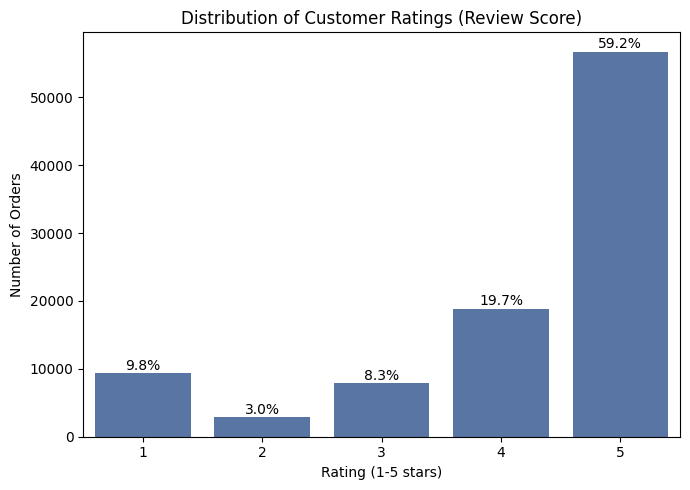

review_score
1     9.761137
2     3.048138
3     8.261591
4    19.710109
5    59.219026
Name: count, dtype: float64
mean: 4.156   skew: -1.483


In [127]:
order_labels = [1, 2, 3, 4, 5]
counts = df_model['review_score'].value_counts().reindex(order_labels).fillna(0).astype(int)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=counts.index, y=counts.values, color='#4C72B0')
plt.title('Distribution of Customer Ratings (Review Score)')
plt.xlabel('Rating (1-5 stars)')
plt.ylabel('Number of Orders')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v/counts.sum()*100:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\01_target_distribution.png')
plt.show()

print(counts / counts.sum() * 100)
print('mean:', df_model['review_score'].mean().round(3), '  skew:', df_model['review_score'].skew().round(3))

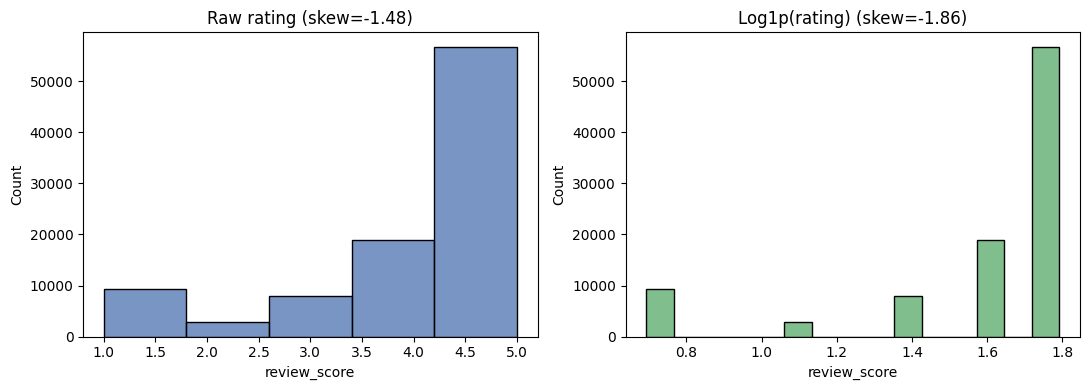

In [128]:
log_score = np.log1p(df_model['review_score'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_model['review_score'], bins=5, ax=axes[0], color='#4C72B0')
axes[0].set_title(f"Raw rating (skew={df_model['review_score'].skew():.2f})")
sns.histplot(log_score, bins=15, ax=axes[1], color='#55A868')
axes[1].set_title(f'Log1p(rating) (skew={log_score.skew():.2f})')
plt.tight_layout()
plt.show()

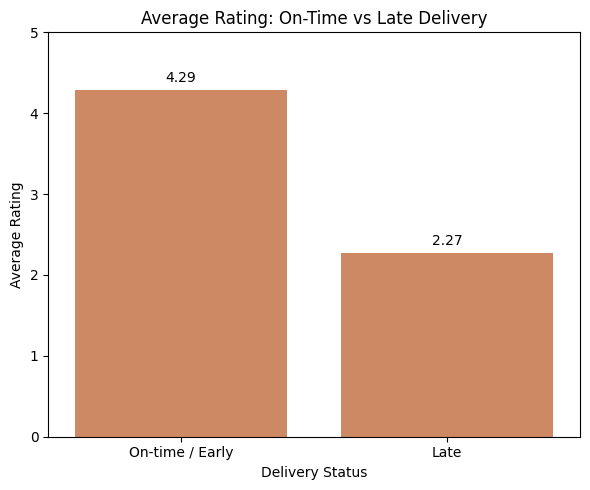

is_late
0    4.290247
1    2.270804
Name: review_score, dtype: float64


In [129]:
late_means = df_model.groupby('is_late')['review_score'].mean()

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=['On-time / Early', 'Late'], y=late_means.values, color='#DD8452')
plt.title('Average Rating: On-Time vs Late Delivery')
plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
for i, v in enumerate(late_means.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\02_rating_by_late_delivery.png')
plt.show()

print(late_means)

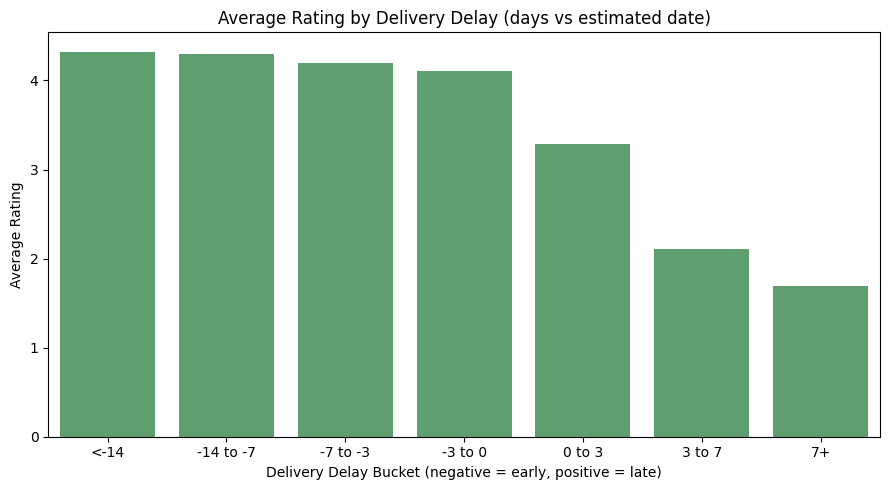

delay_bucket
<-14         4.323891
-14 to -7    4.299118
-7 to -3     4.191431
-3 to 0      4.108197
0 to 3       3.291037
3 to 7       2.102975
7+           1.696872
Name: review_score, dtype: float64


In [130]:
bins = [-999, -14, -7, -3, 0, 3, 7, 999]
labels = ['<-14', '-14 to -7', '-7 to -3', '-3 to 0', '0 to 3', '3 to 7', '7+']
df_model['delay_bucket'] = pd.cut(df_model['delivery_delay_days'], bins=bins, labels=labels)
bucket_means = df_model.groupby('delay_bucket', observed=True)['review_score'].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=bucket_means.index, y=bucket_means.values, color='#55A868')
plt.title('Average Rating by Delivery Delay (days vs estimated date)')
plt.xlabel('Delivery Delay Bucket (negative = early, positive = late)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\03_rating_by_delay_bucket.png')
plt.show()

print(bucket_means)

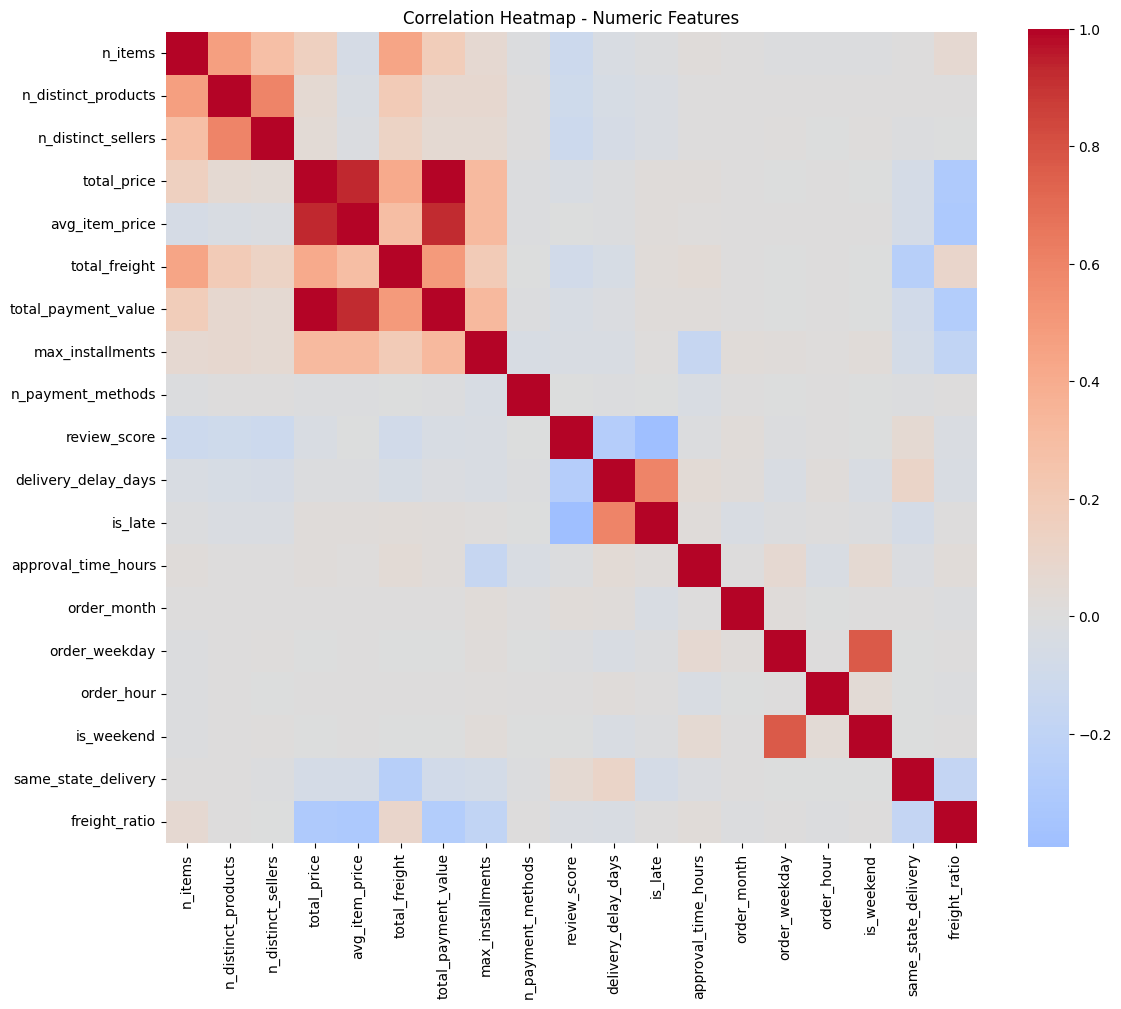

is_late               -0.391828
delivery_delay_days   -0.267029
n_items               -0.122975
n_distinct_sellers    -0.116365
n_distinct_products   -0.105230
total_freight         -0.089604
total_payment_value   -0.041763
total_price           -0.034406
max_installments      -0.031007
freight_ratio         -0.023826
approval_time_hours   -0.015945
order_weekday         -0.009688
avg_item_price        -0.004956
is_weekend            -0.002017
n_payment_methods     -0.001982
order_hour             0.004424
order_month            0.031040
same_state_delivery    0.063328
review_score           1.000000
Name: review_score, dtype: float64


In [131]:
num_cols = df_model.select_dtypes(include='number').columns
corr = df_model[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\04_correlation_heatmap.png')
plt.show()

print(corr['review_score'].sort_values())

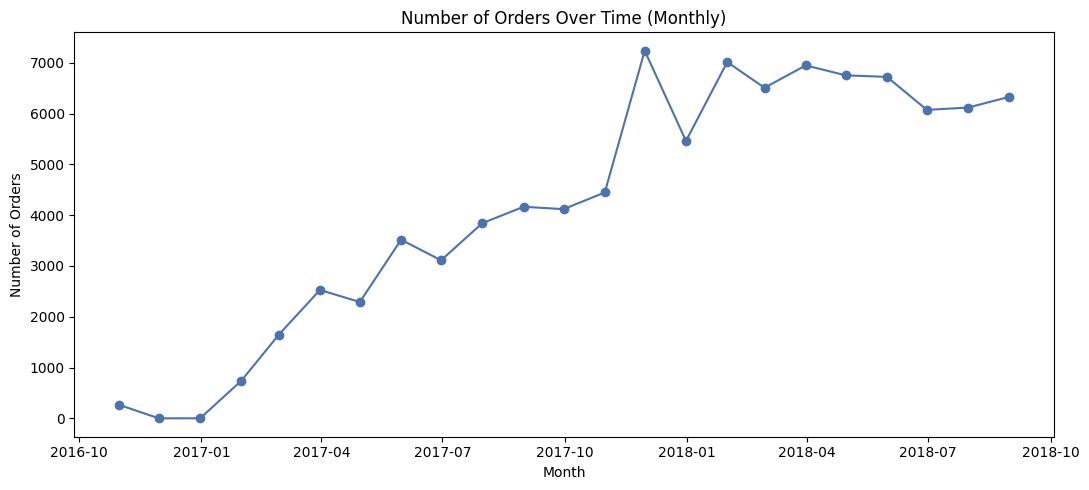

In [132]:
monthly = df.set_index('order_purchase_timestamp').resample('ME').size()

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#4C72B0')
plt.title('Number of Orders Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\05_orders_over_time.png')
plt.show()

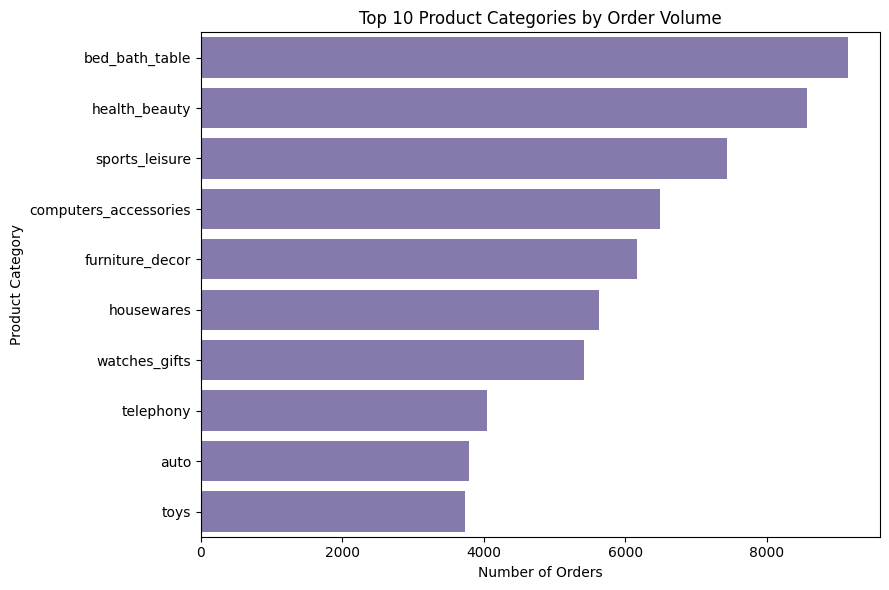

product_category
bed_bath_table           4.002843
telephony                4.058068
furniture_decor          4.072704
computers_accessories    4.082614
watches_gifts            4.129134
auto                     4.146367
housewares               4.206529
health_beauty            4.232393
sports_leisure           4.237423
toys                     4.246447
Name: review_score, dtype: float64


In [133]:
top_cats = df_model['product_category'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(y=top_cats.index, x=top_cats.values, color='#8172B3', orient='h')
plt.title('Top 10 Product Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\06_top_categories.png')
plt.show()

cat_rating = df_model[df_model['product_category'].isin(top_cats.index)].groupby('product_category')['review_score'].mean().sort_values()
print(cat_rating)

## Train & Test Split



In [134]:
df_model = df_model.drop(columns=['delay_bucket'])

y = df_model['review_score']
X = df_model.drop(columns=['review_score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (76663, 23)  X_test: (19166, 23)


### Encoding & Scaling



In [135]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print('categorical columns:', cat_cols)

categorical columns: ['customer_state', 'product_category', 'seller_state', 'payment_type', 'season']


In [136]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()


label_encoders = {}
onehot_cols = []

for col in cat_cols:
    if X_train[col].nunique() > 50:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train[col].astype(str))
        known = set(le.classes_)
        test_vals = X_test[col].astype(str).apply(lambda v: v if v in known else le.classes_[0])
        X_test_enc[col] = le.transform(test_vals)
        label_encoders[col] = le
    else:
        onehot_cols.append(col)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[onehot_cols])

train_ohe = pd.DataFrame(ohe.transform(X_train[onehot_cols]), columns=ohe.get_feature_names_out(onehot_cols), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[onehot_cols]), columns=ohe.get_feature_names_out(onehot_cols), index=X_test.index)

X_train_enc = X_train_enc.drop(columns=onehot_cols).join(train_ohe)
X_test_enc = X_test_enc.drop(columns=onehot_cols).join(test_ohe)

print('encoded shape - train:', X_train_enc.shape, ' test:', X_test_enc.shape)

encoded shape - train: (76663, 76)  test: (19166, 76)


In [137]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns, index=X_train_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns, index=X_test_enc.index)


In [138]:
X_train_scaled.head()

,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,total_payment_value,max_installments,n_payment_methods,delivery_delay_days,is_late,approval_time_hours,order_month,order_weekday,order_hour,is_weekend,same_state_delivery,freight_ratio,customer_state_AC,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,...,seller_state_GO,seller_state_MA,seller_state_MG,seller_state_MS,seller_state_MT,seller_state_PA,seller_state_PB,seller_state_PE,seller_state_PI,seller_state_PR,seller_state_RJ,seller_state_RN,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,season_Autumn,season_Spring,season_Summer,season_Winter
45933,-0.265781,-0.168893,-0.11305,0.260501,0.351558,-0.307252,-1.534411,0.218374,-0.710705,6.523689,-0.205056,-0.267741,-0.487498,1.536397,0.121964,0.981878,-0.545801,-0.749243,-0.731276,-0.02845,-0.063925,-0.039096,-0.024235,-0.187923,-0.116122,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,2.225954,-0.535224,-0.670760
24857,-0.265781,-0.168893,-0.11305,-0.417695,-0.400624,-0.237206,0.074595,-0.422827,-0.710705,-0.153287,-0.008327,-0.267741,-0.455528,-1.252480,-0.386969,0.418012,-0.545801,-0.749243,0.145258,-0.02845,-0.063925,-0.039096,-0.024235,-0.187923,-0.116122,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760
56536,-0.265781,-0.168893,-0.11305,-0.417262,-0.400144,-0.197776,1.260179,-0.418506,-0.710705,-0.153287,-2.369076,-0.267741,-0.489161,-0.012979,0.630897,-0.145855,-0.545801,-0.749243,0.198710,-0.02845,-0.063925,-0.039096,-0.024235,-0.187923,-0.116122,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,-0.535224,1.490847
66478,-0.265781,-0.168893,-0.11305,-0.272965,-0.240106,0.356559,0.709730,-0.225672,-0.341992,-0.153287,0.385131,-0.267741,-0.487242,-1.562355,-0.895903,-0.145855,-0.545801,-0.749243,0.234545,-0.02845,-0.063925,-0.039096,-0.024235,-0.187923,-0.116122,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760
71266,-0.265781,-0.168893,-0.11305,-0.513412,-0.506784,-0.649130,-1.068646,-0.555122,-0.710705,-0.153287,2.254057,3.734954,-0.492973,-1.252480,0.630897,0.981878,-0.545801,1.334681,-0.057331,-0.02845,-0.063925,-0.039096,-0.024235,-0.187923,-0.116122,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760


## Model Training — Compare the 4 Algorithms



In [139]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=1),
    'KNN': KNeighborsRegressor()
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Tuned': 'No'})
    fitted_models[name] = model
    print(f'{name}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

LinearRegression: MAE=0.8887  RMSE=1.1453  R2=0.1909
DecisionTree: MAE=1.0625  RMSE=1.6363  R2=-0.6515
RandomForest: MAE=0.8966  RMSE=1.1495  R2=0.1849
KNN: MAE=0.9159  RMSE=1.2496  R2=0.0368


,Model,MAE,RMSE,R2,Tuned
0,LinearRegression,0.888678,1.145292,0.190923,No
1,RandomForest,0.896641,1.149541,0.184910,No
2,KNN,0.915903,1.249610,0.036823,No
3,DecisionTree,1.062454,1.636307,-0.651531,No


In [140]:

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,Tuned
0,LinearRegression,0.888678,1.145292,0.190923,No
1,RandomForest,0.896641,1.149541,0.184910,No
2,KNN,0.915903,1.249610,0.036823,No
3,DecisionTree,1.062454,1.636307,-0.651531,No


code figure is AI enhanced

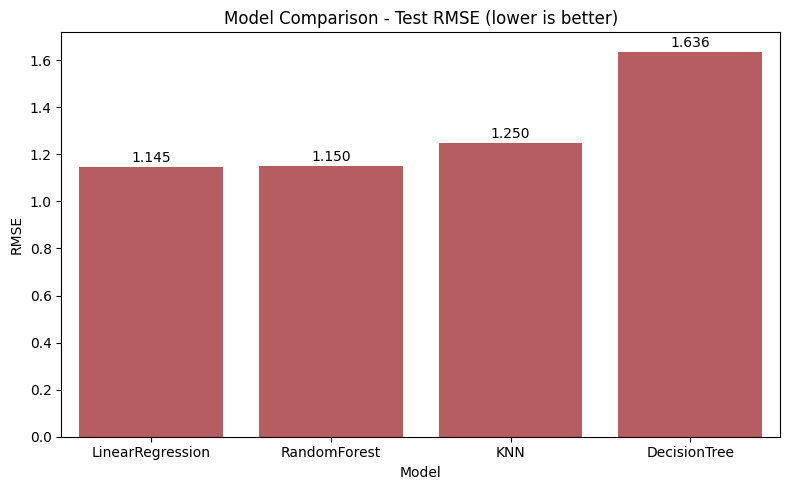

In [141]:
plt.figure(figsize=(8, 5))
comp = results_df.sort_values('RMSE')
ax = sns.barplot(x='Model', y='RMSE', data=comp, color='#C44E52')
plt.title('Model Comparison - Test RMSE (lower is better)')
plt.ylabel('RMSE')
for i, v in enumerate(comp['RMSE']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\07_model_comparison.png')
plt.show()

## Hyperparameter Tuning  **grid search

In [142]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train_scaled.index, size=15000, replace=False)
X_tune = X_train_scaled.loc[sample_idx]
y_tune = y_train.loc[sample_idx]

param_grid = {'n_estimators': [100],'max_depth': [10, 20],'min_samples_leaf': [1, 5]}

grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=1),param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1)
grid.fit(X_tune, y_tune)

print('Best params:', grid.best_params_)
print('Best CV RMSE:', -grid.best_score_)

Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV RMSE: 1.1575082247837265


In [143]:
best_model = RandomForestRegressor(random_state=42, n_jobs=1, **grid.best_params_)
best_model.fit(X_train_scaled, y_train)

preds = best_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f'Tuned Random Forest on TEST set: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

results_df = pd.concat([results_df, pd.DataFrame([{'Model': 'RandomForest (tuned)', 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Tuned': 'Yes'}])], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
results_df

Tuned Random Forest on TEST set: MAE=0.8734  RMSE=1.1300  R2=0.2124


,Model,MAE,RMSE,R2,Tuned
0,RandomForest (tuned),0.873377,1.129960,0.212441,Yes
1,LinearRegression,0.888678,1.145292,0.190923,No
2,RandomForest,0.896641,1.149541,0.184910,No
3,KNN,0.915903,1.249610,0.036823,No
4,DecisionTree,1.062454,1.636307,-0.651531,No


## Final Evaluation

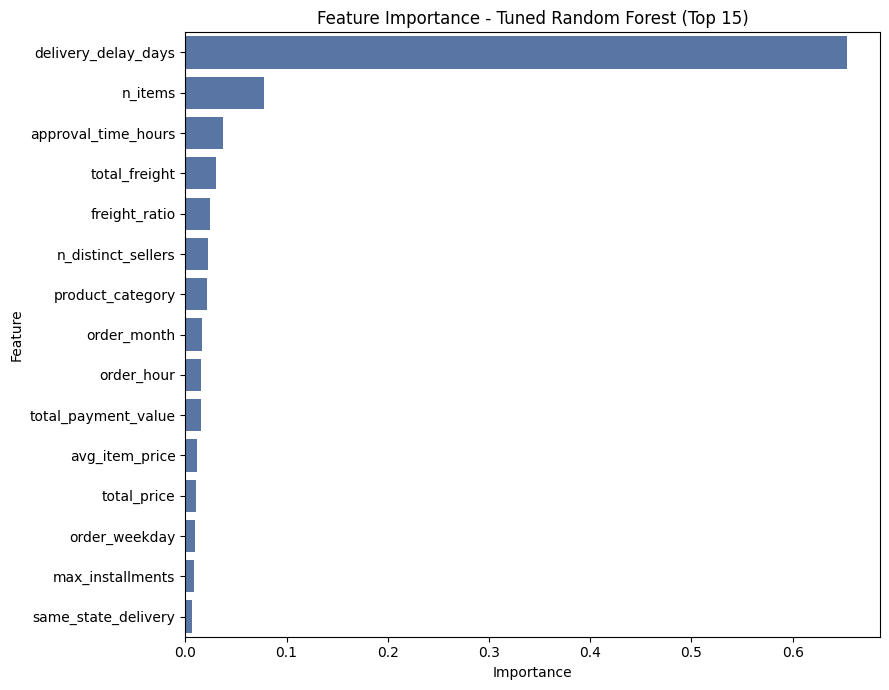

delivery_delay_days    0.653592
n_items                0.077580
approval_time_hours    0.037175
total_freight          0.030048
freight_ratio          0.024542
n_distinct_sellers     0.022812
product_category       0.021919
order_month            0.016983
order_hour             0.015792
total_payment_value    0.015496
avg_item_price         0.011626
total_price            0.010912
order_weekday          0.009959
max_installments       0.008315
same_state_delivery    0.007103
dtype: float64


In [144]:
importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top_imp = importances.head(15)
sns.barplot(y=top_imp.index, x=top_imp.values, color='#4C72B0', orient='h')
plt.title('Feature Importance - Tuned Random Forest (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\08_feature_importance.png')
plt.show()

print(top_imp)

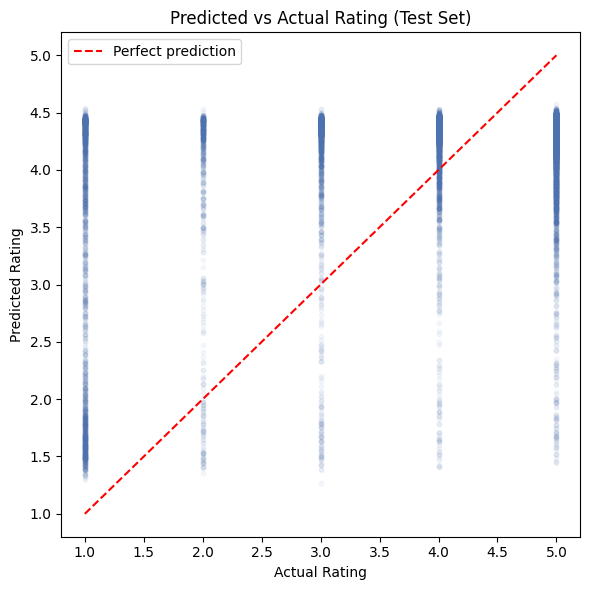

In [145]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.05, s=10, color='#4C72B0')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
plt.title('Predicted vs Actual Rating (Test Set)')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\09_predicted_vs_actual.png')
plt.show()

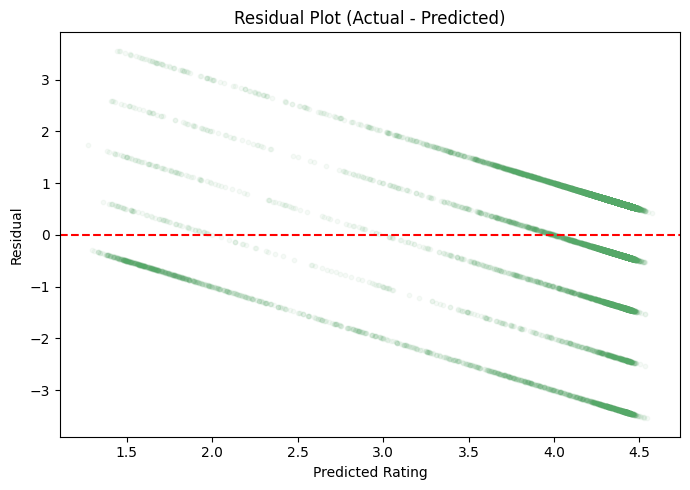

mean residual: 0.0095  std: 1.1299


In [146]:
residuals = y_test.values - preds

plt.figure(figsize=(7, 5))
plt.scatter(preds, residuals, alpha=0.05, s=10, color='#55A868')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Actual - Predicted)')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\10_residual_plot.png')
plt.show()

print('mean residual:', residuals.mean().round(4), ' std:', residuals.std().round(4))

## Export


In [147]:
df.to_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/clean_orders.csv', index=False)
print('saved data/clean_orders.csv:', df.shape)


print("-----------------------------------------------------------------------------------------------------")

joblib.dump(best_model, 'D:/TECHTRECK/level one project/Team_89 _Data_Analysis/model/best_model.pkl')
print('saved model/best_model.pkl')

print("-----------------------------------------------------------------------------------------------------")


results_df.to_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/reports/model_comparison.csv', index=False)
print('saved reports/model_comparison.csv')

results_df

saved data/clean_orders.csv: (95829, 32)
-----------------------------------------------------------------------------------------------------
saved model/best_model.pkl
-----------------------------------------------------------------------------------------------------
saved reports/model_comparison.csv


,Model,MAE,RMSE,R2,Tuned
0,RandomForest (tuned),0.873377,1.129960,0.212441,Yes
1,LinearRegression,0.888678,1.145292,0.190923,No
2,RandomForest,0.896641,1.149541,0.184910,No
3,KNN,0.915903,1.249610,0.036823,No
4,DecisionTree,1.062454,1.636307,-0.651531,No
